In [2]:
!git clone https://github.com/YangtaoWANG95/TokenCut
%cd TokenCut

Cloning into 'TokenCut'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 212 (delta 42), reused 32 (delta 23), pack-reused 150 (from 1)
Receiving objects: 100% (212/212), 7.29 MiB | 16.19 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/content/TokenCut


In [3]:
!pip install torch==1.7.1 torchvision==0.8.2
!pip install -r requirements.txt

ERROR: Could not find a version that satisfies the requirement torch==1.7.1 (from versions: 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1, 2.13.0)
ERROR: No matching distribution found for torch==1.7.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.1 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/05/09/36a4acd1c3112f2e2da74f4340778100a205ecb59166be00dc6287f3364f/catalyst-22.4-py2.py3-none-any.whl (from -r requirements.txt (line 6)) has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.8 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/28/4f/380899b95b45f02182e7163b4e9be4749724c898886d70009168bfd07409/catalyst-22.2.1-py2.py3-none

In [4]:
# Change this URL to any jpg image:
!cd examples && wget -O test.jpg https://i.imgur.com/G4wpITa.jpg

--2026-08-26 13:09:28--  https://i.imgur.com/G4wpITa.jpg
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-08-26 13:09:28 ERROR 429: Unknown Error.



In [9]:
!python main_tokencut.py --image_path /content/TokenCut/examples/VOC07_000012.jpg --visualize all

Since no pretrained weights have been provided, we load the reference pretrained DINO weights.
Pretrained weights found at dino/dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth and loaded with msg: <All keys matched successfully>
Running TokenCut on the dataset VOC07_000012.jpg (exp: TokenCut-vit_small16_k)
  0% 0/1 [00:00<?, ?it/s]Predictions saved at outputs/TokenCut-vit_small16_k/VOC07_000012_TokenCut_pred.jpg.
Eigen attention saved at outputs/TokenCut-vit_small16_k/VOC07_000012_TokenCut_attn.jpg.
100% 1/1 [00:00<00:00,  2.51it/s]
Time cost: 0:00:00.400000


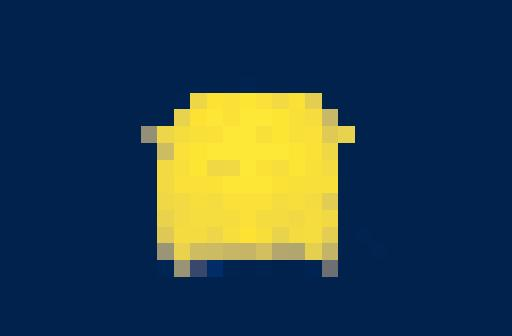

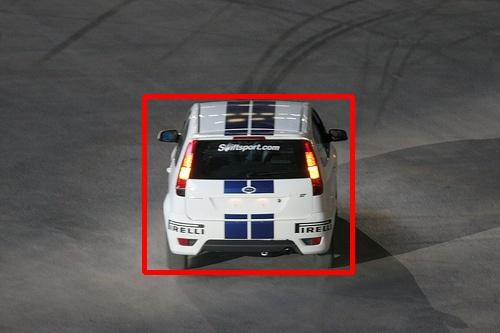

In [10]:
from PIL import Image
display(Image.open(r"/content/TokenCut/outputs/TokenCut-vit_small16_k/VOC07_000012_TokenCut_attn.jpg"))
display(Image.open(r"/content/TokenCut/outputs/TokenCut-vit_small16_k/VOC07_000012_TokenCut_pred.jpg"))

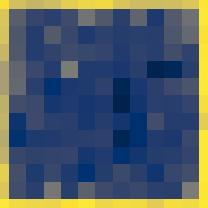

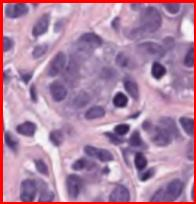

In [8]:
from PIL import Image
display(Image.open(r"/content/TokenCut/outputs/TokenCut-vit_small16_k/tokencut_TokenCut_attn.jpg"))
display(Image.open(r"/content/TokenCut/outputs/TokenCut-vit_small16_k/tokencut_TokenCut_pred.jpg"))

In [ ]:
pip install --upgrade timm

In [7]:
from huggingface_hub import login
login()

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Saved: dinov2_visualization.png


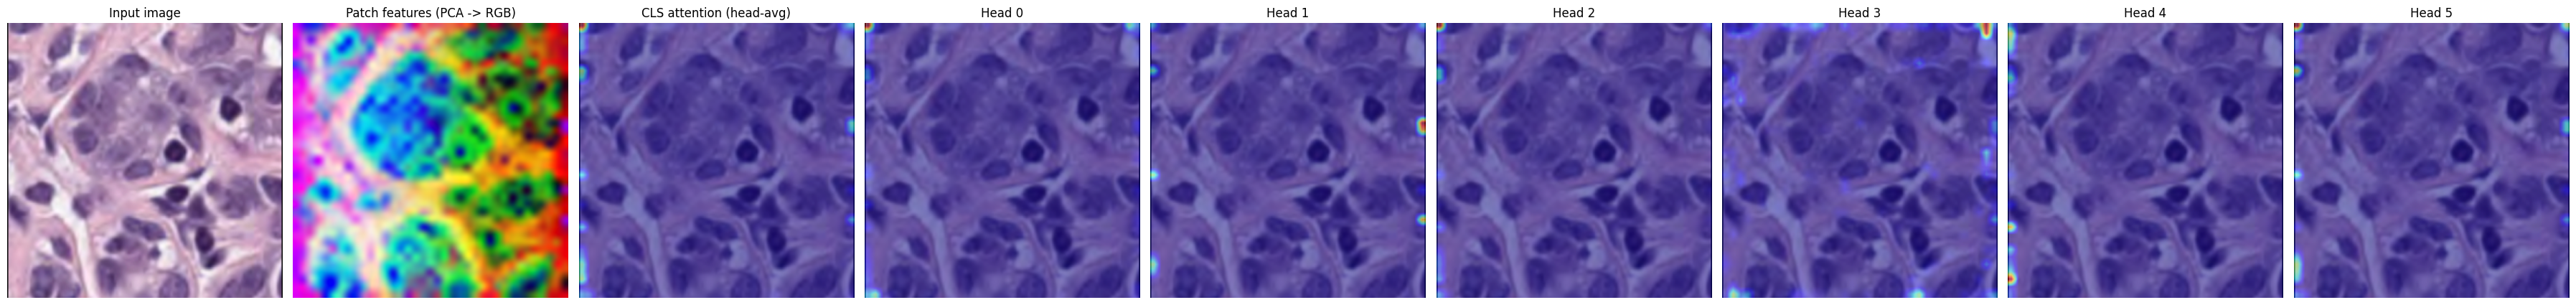

In [10]:
"""
Load DINOv2 and visualize its patch feature map (PCA -> RGB) and
self-attention (CLS token, last block) on a single image.

Install deps:
    pip install torch torchvision pillow matplotlib numpy scikit-learn --break-system-packages

Usage:
    python dinov2_viz.py path/to/image.jpg
"""
import timm
import sys
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.decomposition import PCA
from huggingface_hub import login
from timm.layers import SwiGLUPacked
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 518           # multiple of 14, gives a clean square patch grid
MAX_HEADS_SHOWN = 6      # how many individual attention heads to plot
model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14_reg")
model.eval().to(DEVICE)
model.to("cuda")
img_path =  "/content/tokencut.png"
image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
img_tensor = transform(image).unsqueeze(0).to(DEVICE)  # [1, 3, H, W]
image_resized = np.asarray(image.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
with torch.no_grad():
    feats = model.forward_features(img_tensor)
    patch_tokens = feats["x_norm_patchtokens"][0]  # [num_patches, C]
    num_patches = patch_tokens.shape[0]
    n_patches = int(round(num_patches ** 0.5))      # assumes a square grid

    last_block = model.blocks[-1]
    attn_module = last_block.attn

    tokens_before_last = model.get_intermediate_layers(
        img_tensor, n=2, reshape=False
    )[0]  # input tokens to the last block (CLS [+ registers] + patches)

    B, N, C = tokens_before_last.shape
    num_heads = attn_module.num_heads
    head_dim = C // num_heads
    num_prefix_tokens = N - num_patches  # CLS (+ any register tokens)

    qkv_out = attn_module.qkv(tokens_before_last).reshape(
        B, N, 3, num_heads, head_dim
    ).permute(2, 0, 3, 1, 4)
    q, k, _ = qkv_out[0], qkv_out[1], qkv_out[2]
    attn_scores = (q.float() @ k.float().transpose(-2, -1)) * (head_dim ** -0.5)
    attn_probs = attn_scores.softmax(dim=-1)  # [B, heads, N, N]

    # attention FROM the CLS token TO every patch token, kept PER HEAD
    # (do not average heads here -- averaging washes out sharp, spatially
    # meaningful attention in individual heads)
    cls_attn_heads = attn_probs[0, :, 0, num_prefix_tokens:]  # [heads, num_patches]
    cls_attn_heads = cls_attn_heads.reshape(num_heads, n_patches, n_patches)

    # upsample every head's attention map to full image resolution with
    # bilinear interpolation, instead of a blocky per-patch overlay
    cls_attn_up = F.interpolate(
        cls_attn_heads.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear", align_corners=False
    )[0].cpu().numpy()  # [heads, IMG_SIZE, IMG_SIZE]

mean_attn_up = cls_attn_up.mean(axis=0)

# ---------------------------------------------------------------------------
# 4. Feature-map visualization: whitened PCA + sigmoid stretch for vivid,
#    separable colors (raw min-max normalization looks flat/pastel).
# ---------------------------------------------------------------------------
feat_np = patch_tokens.cpu().numpy()  # [num_patches, C]
pca = PCA(n_components=3, whiten=True)
pca.fit(feat_np)
projected = pca.transform(feat_np)                      # [num_patches, 3]
projected = 1 / (1 + np.exp(-projected * 2.0))           # sigmoid stretch -> [0,1]
feature_map = projected.reshape(n_patches, n_patches, 3)

feature_map_up = F.interpolate(
    torch.from_numpy(feature_map).permute(2, 0, 1).unsqueeze(0).float(),
    size=(IMG_SIZE, IMG_SIZE), mode="bicubic", align_corners=False
)[0].permute(1, 2, 0).clamp(0, 1).numpy()

# ---------------------------------------------------------------------------
# 5. Plot: input | PCA feature map | mean attention | a few individual heads
# ---------------------------------------------------------------------------
def overlay(base_rgb, heat, alpha=0.5, cmap="jet"):
    heat_norm = heat - heat.min()
    heat_norm = heat_norm / (heat_norm.max() + 1e-8)
    heat_rgb = plt.get_cmap(cmap)(heat_norm)[..., :3]
    return alpha * heat_rgb + (1 - alpha) * base_rgb

n_head_panels = min(MAX_HEADS_SHOWN, cls_attn_up.shape[0])
n_cols = 3 + n_head_panels
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.5))

axes[0].imshow(image_resized)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(feature_map_up)
axes[1].set_title("Patch features (PCA -> RGB)")
axes[1].axis("off")

axes[2].imshow(overlay(image_resized, mean_attn_up))
axes[2].set_title("CLS attention (head-avg)")
axes[2].axis("off")

for h in range(n_head_panels):
    axes[3 + h].imshow(overlay(image_resized, cls_attn_up[h]))
    axes[3 + h].set_title(f"Head {h}")
    axes[3 + h].axis("off")

plt.tight_layout()
plt.savefig("dinov2_visualization.png", dpi=150, bbox_inches="tight")
print("Saved: dinov2_visualization.png")
plt.show()

In [ ]:
import torch
import torch.nn as nn


class ViTBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [batch, num_patches, embedding_dim]

        # Multi-head self-attention + residual
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out

        # MLP + residual
        x = x + self.mlp(self.norm2(x))

        return x


# Example
x = torch.randn(2, 196, 768)  # batch=2, patches=196, embedding=768

block = ViTBlock(
    dim=768,
    num_heads=12
)

out = block(x)

print(out.shape)
# torch.Size([2, 196, 768])

Built 115 custom-sized tokens: 59 nucleus tokens (tight, variable size) + 56 background tiles (coarse, uniform size)
Token sequence length: 1 CLS + 115 region tokens = 116 total
Saved: nuclei_custom_size_vit.png


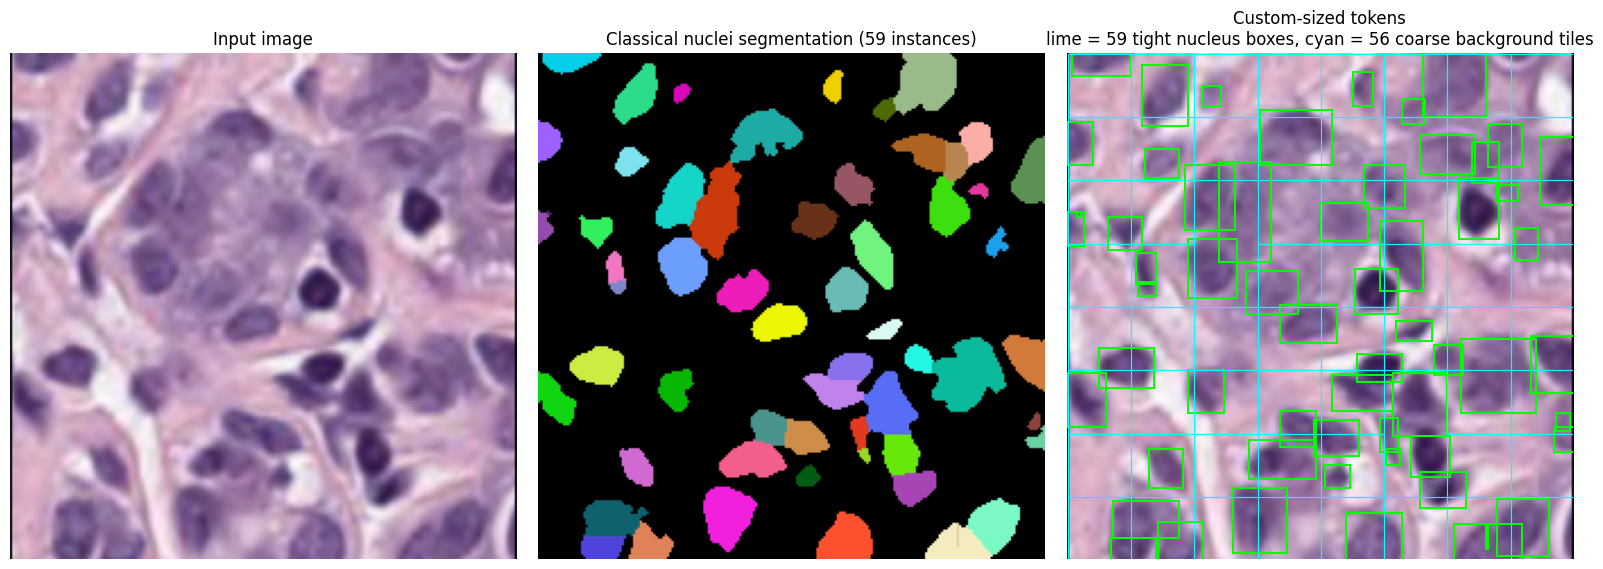

In [17]:
"""
Nuclei-aware ViT with CUSTOM-SIZED tokens.

Difference from the fixed-grid version: instead of forcing every token to
be the same 16x16 patch, each token's region is now:
  - a NUCLEUS token: a tight box exactly matching that nucleus's own
    bounding box (small, tightly fit, variable size/shape per nucleus)
  - a BACKGROUND token: a coarser uniform tile, only placed where there
    isn't already a nucleus covering most of that area

Any region (regardless of pixel size) is turned into a fixed-length token
vector via adaptive average pooling over a dense conv feature map -- the
same trick ROI-Pooling uses in detection models. A learned "box size"
embedding is added too, since pooling alone throws away how big the
region was.

Fun/illustrative demo: random-init weights, no training.
"""

import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from PIL import Image

from skimage.color import rgb2hed
from skimage.exposure import rescale_intensity
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, opening, disk
from skimage.measure import label
from scipy.ndimage import distance_transform_edt, binary_fill_holes
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

IMG_SIZE = 224
FEAT_STRIDE = 8          # dense feature map is IMG_SIZE/FEAT_STRIDE resolution
EMBED_DIM = 96
NUM_HEADS = 4
NUM_LAYERS = 2
BACKGROUND_GRID = 8      # coarse NxN grid for background tiles
BACKGROUND_MAX_NUCLEUS_FRAC = 0.5  # skip a background tile if >50% nucleus


# ---------------------------------------------------------------------------
# 1. Classical nuclei instance segmentation (same as before)
# ---------------------------------------------------------------------------
def segment_nuclei(image_rgb_float):
    hed = rgb2hed(image_rgb_float)
    hematoxylin = rescale_intensity(hed[..., 0], out_range=(0, 1))
    thresh = threshold_otsu(hematoxylin)
    mask = hematoxylin > thresh
    mask = binary_fill_holes(mask)
    mask = opening(mask, disk(1))
    mask = remove_small_objects(mask, min_size=15)

    distance = distance_transform_edt(mask)
    coords = peak_local_max(distance, min_distance=5, labels=mask)
    peak_mask = np.zeros_like(mask, dtype=bool)
    peak_mask[tuple(coords.T)] = True
    markers = label(peak_mask)
    instance_mask = watershed(-distance, markers, mask=mask)
    return instance_mask


# ---------------------------------------------------------------------------
# 2. Build the list of custom-sized token regions
# ---------------------------------------------------------------------------
def build_regions(instance_mask, background_grid=BACKGROUND_GRID):
    H, W = instance_mask.shape
    regions = []

    nucleus_ids = [i for i in np.unique(instance_mask) if i != 0]
    for nid in nucleus_ids:
        ys, xs = np.where(instance_mask == nid)
        y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
        regions.append({"type": "nucleus", "id": int(nid), "box": (y0, y1, x0, x1)})

    tile_h, tile_w = H // background_grid, W // background_grid
    for i in range(background_grid):
        for j in range(background_grid):
            y0, y1 = i * tile_h, (i + 1) * tile_h
            x0, x1 = j * tile_w, (j + 1) * tile_w
            cell = instance_mask[y0:y1, x0:x1]
            nucleus_frac = (cell > 0).mean()
            if nucleus_frac < BACKGROUND_MAX_NUCLEUS_FRAC:
                regions.append({"type": "background", "id": None, "box": (y0, y1, x0, x1)})

    return regions


# ---------------------------------------------------------------------------
# 3. Custom-sized tokenizer + tiny Transformer
# ---------------------------------------------------------------------------
class DenseFeatureExtractor(nn.Module):
    """A tiny conv stack producing a dense feature map at 1/FEAT_STRIDE res."""
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, embed_dim // 2, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(embed_dim, embed_dim, kernel_size=4, stride=2, padding=1), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)  # [B, C, H/8, W/8]


class CustomSizedNucleiViT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS):
        super().__init__()
        self.feature_extractor = DenseFeatureExtractor(embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        self.type_embed = nn.Embedding(2, embed_dim)          # 0=background, 1=nucleus
        self.pos_proj = nn.Linear(2, embed_dim)                # centroid (y, x), normalized
        self.size_proj = nn.Linear(2, embed_dim)               # box (height, width), normalized
        self.token_proj = nn.Linear(embed_dim, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim * 2
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, img_tensor, regions):
        feat_map = self.feature_extractor(img_tensor)  # [1, C, Hf, Wf]
        _, C, Hf, Wf = feat_map.shape

        tokens = []
        for r in regions:
            y0, y1, x0, x1 = r["box"]
            # map region box from pixel space to feature-map space
            fy0 = max(0, min(Hf - 1, int(np.floor(y0 / FEAT_STRIDE))))
            fy1 = max(fy0 + 1, min(Hf, int(np.ceil(y1 / FEAT_STRIDE))))
            fx0 = max(0, min(Wf - 1, int(np.floor(x0 / FEAT_STRIDE))))
            fx1 = max(fx0 + 1, min(Wf, int(np.ceil(x1 / FEAT_STRIDE))))

            roi = feat_map[:, :, fy0:fy1, fx0:fx1]        # variable spatial size!
            pooled = F.adaptive_avg_pool2d(roi, output_size=1).view(1, C)  # -> fixed length

            type_id = torch.tensor([1 if r["type"] == "nucleus" else 0])
            cy = (y0 + y1) / 2 / IMG_SIZE
            cx = (x0 + x1) / 2 / IMG_SIZE
            h = (y1 - y0) / IMG_SIZE
            w = (x1 - x0) / IMG_SIZE

            token = self.token_proj(pooled)
            token = token + self.type_embed(type_id)
            token = token + self.pos_proj(torch.tensor([[cy, cx]], dtype=torch.float32))
            token = token + self.size_proj(torch.tensor([[h, w]], dtype=torch.float32))
            tokens.append(token)

        tokens = torch.cat(tokens, dim=0).unsqueeze(0)  # [1, num_regions, C]
        cls = self.cls_token
        sequence = torch.cat([cls, tokens], dim=1)

        out = self.encoder(sequence)
        return {
            "cls": out[:, 0],
            "region_tokens": out[:, 1:],
        }


# ---------------------------------------------------------------------------
# Run + visualize
# ---------------------------------------------------------------------------
def main():
    image_path =  "/content/tokencut.png"
    image = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    image_np = np.asarray(image).astype(np.float32) / 255.0

    instance_mask = segment_nuclei(image_np)
    regions = build_regions(instance_mask)
    n_nucleus = sum(1 for r in regions if r["type"] == "nucleus")
    n_background = sum(1 for r in regions if r["type"] == "background")
    print(f"Built {len(regions)} custom-sized tokens: "
          f"{n_nucleus} nucleus tokens (tight, variable size) + "
          f"{n_background} background tiles (coarse, uniform size)")

    img_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).float()

    model = CustomSizedNucleiViT()
    model.eval()
    with torch.no_grad():
        result = model(img_tensor, regions)
    print(f"Token sequence length: 1 CLS + {len(regions)} region tokens "
          f"= {1 + len(regions)} total")

    # --- visualize ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

    axes[0].imshow(image_np)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    rng = np.random.default_rng(0)
    colors = rng.random((instance_mask.max() + 1, 3))
    colors[0] = [0, 0, 0]
    axes[1].imshow(instance_mask, cmap=ListedColormap(colors))
    axes[1].set_title(f"Classical nuclei segmentation ({instance_mask.max()} instances)")
    axes[1].axis("off")

    axes[2].imshow(image_np)
    for r in regions:
        y0, y1, x0, x1 = r["box"]
        color = "lime" if r["type"] == "nucleus" else "cyan"
        lw = 1.4 if r["type"] == "nucleus" else 0.8
        axes[2].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                     fill=False, edgecolor=color, linewidth=lw))
    axes[2].set_title(f"Custom-sized tokens\nlime = {n_nucleus} tight nucleus boxes, "
                       f"cyan = {n_background} coarse background tiles")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("nuclei_custom_size_vit.png", dpi=150, bbox_inches="tight")
    print("Saved: nuclei_custom_size_vit.png")


if __name__ == "__main__":
    main()

In [18]:
"""
Train the custom-sized Nuclei-Aware ViT on the PanNuke dataset
(https://huggingface.co/datasets/RationAI/PanNuke) for per-nucleus
classification (Neoplastic / Inflammatory / Connective / Dead / Epithelial).

Dataset schema (per example):
    image:       RGB PIL image, 256x256
    instances:   list of binary masks (mode '1'), one per nucleus
    categories:  list of int labels, 0..4, parallel to `instances`
    tissue:      int tissue-type label (unused here, but available)
Splits: fold1, fold2, fold3

Each nucleus's own instance mask gives an exact bounding box -> a
custom-sized token (no classical segmentation needed, unlike the earlier
"just for fun" demo). Background tiles are added too, on a coarse grid,
so the model also sees non-nucleus context, but only nucleus tokens get a
classification loss.

Install deps:
    pip install torch torchvision datasets pillow numpy tqdm --break-system-packages

Usage:
    python train_pannuke.py
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.ops import roi_align
from datasets import load_dataset
from tqdm import tqdm

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
IMG_SIZE = 256                 # PanNuke images are already 256x256
FEAT_STRIDE = 8
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4
NUM_CLASSES = 5                 # Neoplastic, Inflammatory, Connective, Dead, Epithelial
CLASS_NAMES = ["Neoplastic", "Inflammatory", "Connective", "Dead", "Epithelial"]

BACKGROUND_GRID = 8              # coarse background tile grid
BACKGROUND_MAX_NUCLEUS_FRAC = 0.3
MAX_BACKGROUND_TILES = 16        # cap background tokens per image (keeps batches sane)

BATCH_SIZE = 8
NUM_EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 0.05
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_SPLIT = "fold1"
VAL_SPLIT = "fold2"


# ---------------------------------------------------------------------------
# Dataset: turns each PanNuke example into a list of (box, label, is_nucleus)
# ---------------------------------------------------------------------------
class PanNukeRegionDataset(Dataset):
    def __init__(self, hf_split, background_grid=BACKGROUND_GRID,
                 max_background_tiles=MAX_BACKGROUND_TILES):
        self.ds = hf_split
        self.background_grid = background_grid
        self.max_background_tiles = max_background_tiles

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        example = self.ds[idx]
        image = example["image"].convert("RGB")
        image_np = np.asarray(image).astype(np.float32) / 255.0
        H, W = image_np.shape[:2]

        boxes, labels, is_nucleus_flags = [], [], []
        occupancy = np.zeros((H, W), dtype=bool)

        for inst_img, cat in zip(example["instances"], example["categories"]):
            inst = np.asarray(inst_img)  # mode '1' -> boolean-ish array
            occupancy |= (inst > 0)
            ys, xs = np.where(inst > 0)
            if len(ys) == 0:
                continue
            y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
            x1 = max(x1, x0 + 1)  # guard against degenerate 0-width/height boxes
            y1 = max(y1, y0 + 1)
            boxes.append([float(x0), float(y0), float(x1), float(y1)])
            labels.append(int(cat))
            is_nucleus_flags.append(1)

        tile_h, tile_w = H // self.background_grid, W // self.background_grid
        bg_candidates = []
        for i in range(self.background_grid):
            for j in range(self.background_grid):
                y0, y1 = i * tile_h, (i + 1) * tile_h
                x0, x1 = j * tile_w, (j + 1) * tile_w
                frac = occupancy[y0:y1, x0:x1].mean()
                if frac < BACKGROUND_MAX_NUCLEUS_FRAC:
                    bg_candidates.append([float(x0), float(y0), float(x1), float(y1)])

        if len(bg_candidates) > self.max_background_tiles:
            keep = np.random.choice(len(bg_candidates), self.max_background_tiles, replace=False)
            bg_candidates = [bg_candidates[k] for k in keep]

        for b in bg_candidates:
            boxes.append(b)
            labels.append(-1)   # -1 = ignored in the classification loss
            is_nucleus_flags.append(0)

        if len(boxes) == 0:
            # extremely rare edge case (no nuclei, no background kept) -- fall
            # back to a single whole-image background token so the batch never breaks
            boxes = [[0.0, 0.0, float(W), float(H)]]
            labels = [-1]
            is_nucleus_flags = [0]

        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float()
        return (
            image_tensor,
            torch.tensor(boxes, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
            torch.tensor(is_nucleus_flags, dtype=torch.long),
        )


def collate_fn(batch):
    images = torch.stack([b[0] for b in batch], dim=0)  # all 256x256, safe to stack
    counts = [b[1].shape[0] for b in batch]

    batch_index = torch.cat([torch.full((n,), i, dtype=torch.float32)
                              for i, n in enumerate(counts)])
    boxes_cat = torch.cat([b[1] for b in batch], dim=0)
    roi_boxes = torch.cat([batch_index.unsqueeze(1), boxes_cat], dim=1)  # [K, 5]
    labels_cat = torch.cat([b[2] for b in batch], dim=0)
    is_nucleus_cat = torch.cat([b[3] for b in batch], dim=0)

    return images, roi_boxes, labels_cat, is_nucleus_cat, counts


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------
class DenseFeatureExtractor(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, embed_dim // 2, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(embed_dim, embed_dim, kernel_size=4, stride=2, padding=1), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)  # [B, C, H/8, W/8]


class CustomSizedNucleiViT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 num_classes=NUM_CLASSES, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.feature_extractor = DenseFeatureExtractor(embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        self.type_embed = nn.Embedding(2, embed_dim)   # 0 = background, 1 = nucleus
        self.pos_proj = nn.Linear(2, embed_dim)         # normalized (cy, cx)
        self.size_proj = nn.Linear(2, embed_dim)        # normalized (h, w)
        self.token_proj = nn.Linear(embed_dim, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim * 2
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, images, roi_boxes, is_nucleus, counts):
        B = images.shape[0]
        feat_map = self.feature_extractor(images)          # [B, C, Hf, Wf]
        spatial_scale = feat_map.shape[-1] / self.img_size  # maps image px -> feature px

        # variable-size ROI -> fixed-length vector per region, batched & differentiable
        pooled = roi_align(feat_map, roi_boxes, output_size=1,
                            spatial_scale=spatial_scale, aligned=True)
        pooled = pooled.view(pooled.shape[0], -1)  # [K, C]

        b = roi_boxes[:, 1:]  # x1, y1, x2, y2
        cx = (b[:, 0] + b[:, 2]) / 2 / self.img_size
        cy = (b[:, 1] + b[:, 3]) / 2 / self.img_size
        w = (b[:, 2] - b[:, 0]) / self.img_size
        h = (b[:, 3] - b[:, 1]) / self.img_size

        tokens = self.token_proj(pooled)
        tokens = tokens + self.type_embed(is_nucleus)
        tokens = tokens + self.pos_proj(torch.stack([cy, cx], dim=1))
        tokens = tokens + self.size_proj(torch.stack([h, w], dim=1))

        # pack the flat [K, C] tokens into a padded [B, max_len, C] sequence
        splits = torch.split(tokens, counts)
        max_len = max(counts)
        padded = tokens.new_zeros(B, max_len, tokens.shape[-1])
        pad_mask = torch.ones(B, max_len, dtype=torch.bool, device=tokens.device)
        for i, seq in enumerate(splits):
            n = seq.shape[0]
            padded[i, :n] = seq
            pad_mask[i, :n] = False

        cls = self.cls_token.expand(B, -1, -1)
        cls_pad = torch.zeros(B, 1, dtype=torch.bool, device=tokens.device)
        seq_in = torch.cat([cls, padded], dim=1)
        full_pad_mask = torch.cat([cls_pad, pad_mask], dim=1)

        out = self.encoder(seq_in, src_key_padding_mask=full_pad_mask)
        region_out_padded = out[:, 1:]  # [B, max_len, C]

        # unpad back to flat [K, C], same order as the input tokens
        region_out_flat = torch.cat(
            [region_out_padded[i, :n] for i, n in enumerate(counts)], dim=0
        )
        logits = self.classifier(region_out_flat)  # [K, num_classes]
        return logits


# ---------------------------------------------------------------------------
# Class weights (handles PanNuke's strong imbalance, e.g. rare "Dead" class)
# ---------------------------------------------------------------------------
def compute_class_weights(hf_split, num_classes=NUM_CLASSES):
    counts = np.zeros(num_classes, dtype=np.float64)
    for cats in hf_split["categories"]:
        for c in cats:
            counts[c] += 1
    counts = np.clip(counts, 1, None)
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


# ---------------------------------------------------------------------------
# Train / eval loops
# ---------------------------------------------------------------------------
def run_epoch(model, loader, optimizer, class_weights, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    per_class_correct = np.zeros(NUM_CLASSES)
    per_class_total = np.zeros(NUM_CLASSES)

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, roi_boxes, labels, is_nucleus, counts in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            roi_boxes = roi_boxes.to(DEVICE)
            labels = labels.to(DEVICE)
            is_nucleus = is_nucleus.to(DEVICE)

            logits = model(images, roi_boxes, is_nucleus, counts)

            mask = labels >= 0
            if mask.sum() == 0:
                continue
            loss = F.cross_entropy(logits[mask], labels[mask],
                                    weight=class_weights.to(DEVICE))

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            n = mask.sum().item()
            total_loss += loss.item() * n
            total_count += n
            preds = logits[mask].argmax(dim=1)
            correct = (preds == labels[mask])
            total_correct += correct.sum().item()

            for c in range(NUM_CLASSES):
                cls_mask = labels[mask] == c
                per_class_total[c] += cls_mask.sum().item()
                per_class_correct[c] += (correct & cls_mask).sum().item()

    avg_loss = total_loss / max(total_count, 1)
    acc = total_correct / max(total_count, 1)
    per_class_acc = per_class_correct / np.clip(per_class_total, 1, None)
    return avg_loss, acc, per_class_acc


def main():
    print("Loading PanNuke...")
    dataset = load_dataset("RationAI/PanNuke")

    print("Computing class weights from training split...")
    class_weights = compute_class_weights(dataset[TRAIN_SPLIT])
    print("Class weights:", dict(zip(CLASS_NAMES, class_weights.tolist())))

    train_ds = PanNukeRegionDataset(dataset[TRAIN_SPLIT])
    val_ds = PanNukeRegionDataset(dataset[VAL_SPLIT])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               collate_fn=collate_fn, num_workers=4)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             collate_fn=collate_fn, num_workers=4)

    model = CustomSizedNucleiViT().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc = 0.0
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc, _ = run_epoch(model, train_loader, optimizer, class_weights, train=True)
        val_loss, val_acc, val_per_class = run_epoch(model, val_loader, optimizer, class_weights, train=False)
        scheduler.step()

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f}")
        for name, acc in zip(CLASS_NAMES, val_per_class):
            print(f"    {name:>13}: {acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_nuclei_vit.pt")
            print(f"  -> saved new best checkpoint (val acc {val_acc:.4f})")


if __name__ == "__main__":
    main()

Loading PanNuke...


README.md:   0%|          | 0.00/4.53k [00:00<?, ?B/s]

data/fold1-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  280MB            

data/fold1-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/fold2-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  264MB            

...

Epoch 16/20 | train loss 0.6165 acc 0.7424 | val loss 0.7549 acc 0.7121
       Neoplastic: 0.7547
     Inflammatory: 0.7441
       Connective: 0.5932
             Dead: 0.8235
       Epithelial: 0.7785
  -> saved new best checkpoint (val acc 0.7121)


Epoch 17/20 | train loss 0.5999 acc 0.7510 | val loss 0.7581 acc 0.7149
       Neoplastic: 0.7433
     Inflammatory: 0.7238
       Connective: 0.6249
             Dead: 0.7941
       Epithelial: 0.7935
  -> saved new best checkpoint (val acc 0.7149)


Epoch 18/20 | train loss 0.5872 acc 0.7575 | val loss 0.7423 acc 0.7205
       Neoplastic: 0.7621
     Inflammatory: 0.7623
       Connective: 0.6038
             Dead: 0.8009
       Epithelial: 0.7766
  -> saved new best checkpoint (val acc 0.7205)


Epoch 19/20 | train loss 0.5802 acc 0.7611 | val loss 0.7362 acc 0.7250
       Neoplastic: 0.7765
     Inflammatory: 0.7548
       Connective: 0.6100
             Dead: 0.8167
       Epithelial: 0.7656
  -> saved new best checkpoint (val acc 0.7250)


Epoch 20/20 | train loss 0.5769 acc 0.7641 | val loss 0.7357 acc 0.7217
       Neoplastic: 0.7751
     Inflammatory: 0.7500
       Connective: 0.6045
             Dead: 0.8088
       Epithelial: 0.7635


In [20]:
"""
Visualization utilities for the self-supervised Nuclei-Aware ViT.

Three views, meant to be called periodically on the SAME fixed sample
image throughout training so you can compare snapshots over time:

  1. visualize_tokenization -- how custom-sized tokens are built
     (tight boxes for nuclei, coarse tiles for background)
  2. visualize_pca          -- what the model has learned: nucleus-token
     embeddings projected via PCA to RGB, optionally next to a panel
     colored by the TRUE PanNuke category (diagnostic only -- categories
     are never used in training, only to check whether the unsupervised
     embedding clusters happen to align with real nucleus types)
  3. visualize_attention    -- how the CLS token's attention over the
     region tokens evolves, drawn as a heatmap over each token's box
"""

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

CLASS_NAMES = ["Neoplastic", "Inflammatory", "Connective", "Dead", "Epithelial"]


# ---------------------------------------------------------------------------
# 1. Tokenization
# ---------------------------------------------------------------------------
def visualize_tokenization(image_np, regions, save_path, title_suffix=""):
    n_nucleus = sum(1 for r in regions if r["type"] == "nucleus")
    n_background = sum(1 for r in regions if r["type"] == "background")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np)
    for r in regions:
        y0, y1, x0, x1 = r["box"]
        color = "lime" if r["type"] == "nucleus" else "cyan"
        lw = 1.3 if r["type"] == "nucleus" else 0.6
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                fill=False, edgecolor=color, linewidth=lw))
    ax.set_title(f"Tokenization {title_suffix}\n"
                 f"lime = {n_nucleus} nucleus tokens, cyan = {n_background} background tiles")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
# 2. What the model has learned: PCA over nucleus-token embeddings
# ---------------------------------------------------------------------------
def visualize_pca(image_np, regions, region_embeddings, save_path,
                   id_to_category=None, title_suffix=""):
    """
    region_embeddings: numpy [N_regions, C], same order as `regions`
    id_to_category: optional dict {nucleus_id: category_int}. If given
        (and every region carries an 'id' key for nucleus regions), a
        second panel colored by TRUE category is drawn for comparison.
        This is a diagnostic view only -- never used in training.
    """
    nucleus_idx = [i for i, r in enumerate(regions) if r["type"] == "nucleus"]
    show_labels = id_to_category is not None and len(nucleus_idx) >= 3

    n_panels = 2 if show_labels else 1
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
    axes = [axes] if n_panels == 1 else list(axes)

    axes[0].imshow(image_np)
    if len(nucleus_idx) >= 3:
        feats = region_embeddings[nucleus_idx]
        n_components = min(3, feats.shape[0] - 1, feats.shape[1])
        pca = PCA(n_components=max(n_components, 1))
        proj = pca.fit_transform(feats)
        if proj.shape[1] < 3:
            proj = np.pad(proj, ((0, 0), (0, 3 - proj.shape[1])))
        proj = 1 / (1 + np.exp(-proj[:, :3] * 2.0))  # sigmoid stretch -> vivid RGB

        for idx, color in zip(nucleus_idx, proj):
            y0, y1, x0, x1 = regions[idx]["box"]
            axes[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                         facecolor=tuple(color), edgecolor="white",
                                         linewidth=0.4, alpha=0.85))
    axes[0].set_title(f"Nucleus embeddings (PCA -> RGB) {title_suffix}")
    axes[0].axis("off")

    if show_labels:
        axes[1].imshow(image_np)
        cmap = ListedColormap(plt.cm.tab10.colors[:len(CLASS_NAMES)])
        for idx in nucleus_idx:
            r = regions[idx]
            cat = id_to_category.get(r.get("id"))
            if cat is None:
                continue
            y0, y1, x0, x1 = r["box"]
            axes[1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                         facecolor=cmap(cat), edgecolor="white",
                                         linewidth=0.4, alpha=0.85))
        handles = [Rectangle((0, 0), 1, 1, facecolor=cmap(i)) for i in range(len(CLASS_NAMES))]
        axes[1].legend(handles, CLASS_NAMES, loc="upper right", fontsize=7, framealpha=0.8)
        axes[1].set_title("True PanNuke category (eval-only, not used in training)")
        axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
# 3. Attention evolution: CLS -> region-token attention, drawn on boxes
# ---------------------------------------------------------------------------
def visualize_attention(image_np, regions, cls_attn, save_path, title_suffix=""):
    """cls_attn: 1D array/tensor, one weight per region, same order as `regions`."""
    cls_attn_np = cls_attn.detach().cpu().numpy() if torch.is_tensor(cls_attn) else np.asarray(cls_attn)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np)
    vmin, vmax = cls_attn_np.min(), cls_attn_np.max() + 1e-8
    cmap = plt.get_cmap("jet")
    for r, a in zip(regions, cls_attn_np):
        y0, y1, x0, x1 = r["box"]
        color = cmap((a - vmin) / (vmax - vmin))
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                facecolor=color, edgecolor="none", alpha=0.55))
    ax.set_title(f"CLS token attention over tokens {title_suffix}")
    ax.axis("off")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
# Convenience: run all three on a fixed sample and tag filenames with `step`
# ---------------------------------------------------------------------------
def visualize_all(model, image_np, regions, step, out_dir, id_to_category=None):
    os.makedirs(out_dir, exist_ok=True)
    img_size = image_np.shape[0]
    img_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).float()
    img_tensor = img_tensor.to(next(model.parameters()).device)

    was_training = model.training
    model.eval()
    with torch.no_grad():
        cls_out, region_out, attn_weights = model.forward_with_attention(img_tensor, regions, img_size)
        # attn_weights: [heads, N_total, N_total], token 0 = CLS, tokens 1: = regions
        cls_attn = attn_weights[:, 0, 1:].mean(dim=0)   # average over heads -> [N_regions]
        region_embeddings = region_out[0].cpu().numpy()  # [N_regions, C]
    if was_training:
        model.train()

    tag = f"step{step:06d}"
    visualize_tokenization(image_np, regions, os.path.join(out_dir, f"{tag}_tokenization.png"),
                            title_suffix=f"(step {step})")
    visualize_pca(image_np, regions, region_embeddings, os.path.join(out_dir, f"{tag}_pca.png"),
                  id_to_category=id_to_category, title_suffix=f"(step {step})")
    visualize_attention(image_np, regions, cls_attn, os.path.join(out_dir, f"{tag}_attention.png"),
                         title_suffix=f"(step {step})")

In [ ]:
"""
Self-supervised pretraining of the custom-sized Nuclei-Aware ViT via
DINO-style self-distillation.

No category labels are used anywhere in the training objective -- the
entire self-supervised signal is the student matching the teacher's
output distribution across different crops of the same image (standard
DINO). That is what makes this self-supervised, not whether nucleus
*boundaries* are known.

Nucleus boundaries ARE taken from PanNuke's ground-truth instance masks
here (cropped/resized alongside the image), purely to define each
token's region -- this is structural information, not a semantic label,
so it doesn't leak supervision into the loss. Using the real masks
instead of classical segmentation is faster and far more accurate than
per-crop stain deconvolution + watershed, at the cost of tying this
script specifically to datasets that ship instance masks (PanNuke does).
If you need this to run on arbitrary unlabeled images with no masks
available, swap `build_regions_from_mask` for the classical
`segment_nuclei` + `build_regions` pair from the earlier version.

How it matches DINOv2's own recipe:
  - A teacher and a student share the same architecture; the teacher's
    weights are an exponential moving average (EMA) of the student's.
  - Each image produces several random crops: a couple of large "global"
    crops and several small "local" crops (standard DINO multi-crop).
  - The teacher only ever sees the global crops. The student sees every
    crop (global + local).
  - The student is trained so its output distribution matches the
    teacher's (sharpened, centered) output distribution for the SAME
    image, across different crops -- this is the entire self-supervised
    signal.

Also periodically visualizes, on a fixed held-out sample, throughout
training (see nuclei_viz.py):
  - how custom-sized tokens are being built
  - what the model has learned (PCA over nucleus-token embeddings, plus
    an optional side-by-side against TRUE PanNuke categories -- shown
    only for inspection, never used anywhere in the training loss)
  - how the CLS token's attention over region tokens evolves

Install deps:
    pip install torch torchvision datasets pillow numpy scikit-learn matplotlib tqdm --break-system-packages

Usage:
    python train_pannuke_ssl_v3.py
"""

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.ops import roi_align
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm



# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4
DINO_OUT_DIM = 4096
DINO_HIDDEN_DIM = 256
DINO_BOTTLENECK_DIM = 64

N_GLOBAL_CROPS = 2
N_LOCAL_CROPS = 4
GLOBAL_CROP_SIZE = 192
LOCAL_CROP_SIZE = 96
GLOBAL_SCALE = (0.4, 1.0)     # fraction of image area for global crops
LOCAL_SCALE = (0.05, 0.4)     # fraction of image area for local crops

BACKGROUND_GRID = 6
BACKGROUND_MAX_NUCLEUS_FRAC = 0.3

STUDENT_TEMP = 0.1
TEACHER_TEMP = 0.04
CENTER_MOMENTUM = 0.9
EMA_MOMENTUM = 0.996            # teacher = EMA of student

BATCH_SIZE = 4                  # images per optimizer step (grad accumulated across images)
NUM_STEPS = 2000
LR = 5e-4
WEIGHT_DECAY = 0.04
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_SPLIT = "fold1"

VIS_EVERY = 100          # save tokenization/PCA/attention snapshots every N steps
VIS_OUT_DIR = "viz"


# ---------------------------------------------------------------------------
# Build an instance mask directly from PanNuke's ground-truth per-nucleus
# binary masks (structural info only -- NOT the `categories` labels).
# ---------------------------------------------------------------------------
def build_instance_mask_from_pannuke(example):
    """example['instances'] is a list of binary masks (mode '1'), one per
    nucleus. Stamp each one into a single (H, W) int array with a unique id."""
    h, w = np.asarray(example["image"]).shape[:2]
    instance_mask = np.zeros((h, w), dtype=np.int32)
    for i, inst_img in enumerate(example["instances"], start=1):
        inst = np.asarray(inst_img)
        instance_mask[inst > 0] = i
    return instance_mask


def build_id_to_category(example):
    """Diagnostic-only lookup {nucleus_id: category_int}, for checking whether
    unsupervised embeddings happen to align with true nucleus types. Never
    used anywhere in the training loss."""
    return {i: int(cat) for i, cat in enumerate(example.get("categories", []), start=1)}


def build_regions(instance_mask, background_grid=BACKGROUND_GRID):
    H, W = instance_mask.shape
    regions = []

    nucleus_ids = [i for i in np.unique(instance_mask) if i != 0]
    for nid in nucleus_ids:
        ys, xs = np.where(instance_mask == nid)
        y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
        y1, x1 = max(y1, y0 + 1), max(x1, x0 + 1)
        regions.append({"type": "nucleus", "box": (y0, y1, x0, x1), "id": int(nid)})

    tile_h, tile_w = max(H // background_grid, 1), max(W // background_grid, 1)
    for i in range(background_grid):
        for j in range(background_grid):
            y0, y1 = i * tile_h, min((i + 1) * tile_h, H)
            x0, x1 = j * tile_w, min((j + 1) * tile_w, W)
            if y1 <= y0 or x1 <= x0:
                continue
            cell = instance_mask[y0:y1, x0:x1]
            if (cell > 0).mean() < BACKGROUND_MAX_NUCLEUS_FRAC:
                regions.append({"type": "background", "box": (y0, y1, x0, x1)})

    if not regions:
        regions.append({"type": "background", "box": (0, H, 0, W)})
    return regions


# ---------------------------------------------------------------------------
# Multi-crop augmentation, applied identically to the image and its
# instance mask so token regions stay aligned to the cropped image
# ---------------------------------------------------------------------------
def random_resized_crop_with_mask(image_np, instance_mask, out_size, scale_range):
    H, W, _ = image_np.shape
    area = H * W
    for _ in range(10):
        target_area = np.random.uniform(*scale_range) * area
        aspect = np.random.uniform(3 / 4, 4 / 3)
        w = int(round(np.sqrt(target_area * aspect)))
        h = int(round(np.sqrt(target_area / aspect)))
        if 0 < w <= W and 0 < h <= H:
            x0 = np.random.randint(0, W - w + 1)
            y0 = np.random.randint(0, H - h + 1)
            img_crop = image_np[y0:y0 + h, x0:x0 + w]
            mask_crop = instance_mask[y0:y0 + h, x0:x0 + w]
            break
    else:
        img_crop, mask_crop = image_np, instance_mask  # fallback: whole image

    img_pil = Image.fromarray((img_crop * 255).astype(np.uint8)).resize(
        (out_size, out_size), Image.BILINEAR
    )
    img_out = np.asarray(img_pil).astype(np.float32) / 255.0

    # nearest-neighbor for the mask -- bilinear would blend instance ids
    mask_pil = Image.fromarray(mask_crop.astype(np.int32), mode="I").resize(
        (out_size, out_size), Image.NEAREST
    )
    mask_out = np.array(mask_pil)

    if np.random.rand() < 0.5:
        img_out = img_out[:, ::-1, :].copy()
        mask_out = mask_out[:, ::-1].copy()

    return img_out, mask_out


def make_multicrop(image_np, instance_mask):
    crops = []
    for _ in range(N_GLOBAL_CROPS):
        img_c, mask_c = random_resized_crop_with_mask(
            image_np, instance_mask, GLOBAL_CROP_SIZE, GLOBAL_SCALE
        )
        crops.append(("global", img_c, mask_c))
    for _ in range(N_LOCAL_CROPS):
        img_c, mask_c = random_resized_crop_with_mask(
            image_np, instance_mask, LOCAL_CROP_SIZE, LOCAL_SCALE
        )
        crops.append(("local", img_c, mask_c))
    return crops


# ---------------------------------------------------------------------------
# Backbone: custom-sized nuclei-aware tokenizer + Transformer, single image in
# ---------------------------------------------------------------------------
class DenseFeatureExtractor(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, embed_dim // 2, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(embed_dim, embed_dim, kernel_size=4, stride=2, padding=1), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class CustomSizedNucleiBackbone(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS):
        super().__init__()
        self.feature_extractor = DenseFeatureExtractor(embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.type_embed = nn.Embedding(2, embed_dim)
        self.pos_proj = nn.Linear(2, embed_dim)
        self.size_proj = nn.Linear(2, embed_dim)
        self.token_proj = nn.Linear(embed_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim * 2
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def build_sequence(self, img_tensor, regions, img_size):
        """Builds the [1, 1+N_regions, C] input sequence (CLS + region tokens),
        before the Transformer encoder. Shared by forward() and
        forward_with_attention() so both stay perfectly in sync."""
        feat_map = self.feature_extractor(img_tensor)
        spatial_scale = feat_map.shape[-1] / img_size

        boxes, type_ids, centers, sizes = [], [], [], []
        for r in regions:
            y0, y1, x0, x1 = r["box"]
            boxes.append([0.0, float(x0), float(y0), float(x1), float(y1)])
            type_ids.append(1 if r["type"] == "nucleus" else 0)
            centers.append([(y0 + y1) / 2 / img_size, (x0 + x1) / 2 / img_size])
            sizes.append([(y1 - y0) / img_size, (x1 - x0) / img_size])

        boxes = torch.tensor(boxes, dtype=torch.float32, device=img_tensor.device)
        type_ids = torch.tensor(type_ids, dtype=torch.long, device=img_tensor.device)
        centers = torch.tensor(centers, dtype=torch.float32, device=img_tensor.device)
        sizes = torch.tensor(sizes, dtype=torch.float32, device=img_tensor.device)

        pooled = roi_align(feat_map, boxes, output_size=1, spatial_scale=spatial_scale, aligned=True)
        pooled = pooled.view(pooled.shape[0], -1)

        tokens = self.token_proj(pooled)
        tokens = tokens + self.type_embed(type_ids)
        tokens = tokens + self.pos_proj(centers)
        tokens = tokens + self.size_proj(sizes)

        cls = self.cls_token
        return torch.cat([cls, tokens.unsqueeze(0)], dim=1)  # [1, 1+N, C]

    def forward(self, img_tensor, regions, img_size, return_tokens=False):
        """Returns CLS embedding [1, C], or (CLS, region_tokens) if return_tokens=True."""
        sequence = self.build_sequence(img_tensor, regions, img_size)
        out = self.encoder(sequence)
        if return_tokens:
            return out[:, 0], out[:, 1:]
        return out[:, 0]

    def forward_with_attention(self, img_tensor, regions, img_size):
        """For visualization: returns (CLS, region_tokens, attn_weights) where
        attn_weights is the LAST encoder layer's self-attention, per head,
        shape [heads, 1+N_regions, 1+N_regions] (token 0 = CLS)."""
        sequence = self.build_sequence(img_tensor, regions, img_size)

        x = sequence
        for layer in self.encoder.layers[:-1]:
            x = layer(x)
        last_layer = self.encoder.layers[-1]
        _, attn_weights = last_layer.self_attn(
            x, x, x, need_weights=True, average_attn_weights=False
        )  # attn_weights: [1, heads, N, N]

        out = self.encoder(sequence)  # separate, un-truncated pass for the real output
        return out[:, 0], out[:, 1:], attn_weights[0]


class DINOHead(nn.Module):
    """Standard DINO projection head: MLP -> L2 normalize -> weight-normalized linear."""
    def __init__(self, in_dim, out_dim=DINO_OUT_DIM, hidden_dim=DINO_HIDDEN_DIM,
                 bottleneck_dim=DINO_BOTTLENECK_DIM):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.parametrizations.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )
        self.last_layer.parametrizations.weight.original0.data.fill_(1)
        self.last_layer.parametrizations.weight.original0.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)


class NucleiDINO(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CustomSizedNucleiBackbone()
        self.head = DINOHead(EMBED_DIM)

    def forward(self, img_tensor, regions, img_size):
        emb = self.backbone(img_tensor, regions, img_size)
        return self.head(emb)

    def forward_with_attention(self, img_tensor, regions, img_size):
        return self.backbone.forward_with_attention(img_tensor, regions, img_size)


# ---------------------------------------------------------------------------
# DINO loss (cross-entropy between teacher's sharpened+centered dist and
# student's dist, summed over all valid crop pairs)
# ---------------------------------------------------------------------------
class DINOLoss(nn.Module):
    def __init__(self, out_dim=DINO_OUT_DIM, student_temp=STUDENT_TEMP,
                 teacher_temp=TEACHER_TEMP, center_momentum=CENTER_MOMENTUM):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_outputs, teacher_outputs):
        """
        student_outputs: list of [1, out_dim] tensors, one per crop (global+local)
        teacher_outputs: list of [1, out_dim] tensors, one per GLOBAL crop only
        """
        student_logp = [F.log_softmax(s / self.student_temp, dim=-1) for s in student_outputs]
        teacher_p = [F.softmax((t - self.center) / self.teacher_temp, dim=-1).detach()
                     for t in teacher_outputs]

        total_loss, n_terms = 0.0, 0
        for ti, tp in enumerate(teacher_p):
            for si, slogp in enumerate(student_logp):
                if si == ti:  # don't compare a view to itself
                    continue
                total_loss = total_loss + torch.sum(-tp * slogp, dim=-1).mean()
                n_terms += 1
        total_loss = total_loss / max(n_terms, 1)

        self.update_center(torch.cat(teacher_outputs, dim=0))
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        self.center.mul_(self.center_momentum).add_(batch_center, alpha=1 - self.center_momentum)


@torch.no_grad()
def update_teacher(student, teacher, momentum):
    for p_s, p_t in zip(student.parameters(), teacher.parameters()):
        p_t.data.mul_(momentum).add_(p_s.data, alpha=1 - momentum)


# ---------------------------------------------------------------------------
# Dataset: image + instance mask. `categories` (the semantic labels) is
# never read -- only `instances` (nucleus boundaries) is used, and only to
# define token regions, not as a training target.
# ---------------------------------------------------------------------------
class ImageMaskDataset(Dataset):
    def __init__(self, hf_split):
        self.ds = hf_split

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        example = self.ds[idx]
        image = example["image"].convert("RGB")
        image_np = np.asarray(image).astype(np.float32) / 255.0
        instance_mask = build_instance_mask_from_pannuke(example)
        return image_np, instance_mask


def image_collate(batch):
    return list(batch)  # list of (image_np, instance_mask) pairs


# ---------------------------------------------------------------------------
# One training step for a single image: build multi-crop views, run
# student on all crops + teacher on global crops only, compute DINO loss
# ---------------------------------------------------------------------------
def process_one_image(image_np, instance_mask, student, teacher, dino_loss):
    crops = make_multicrop(image_np, instance_mask)

    student_outputs, teacher_outputs = [], []
    for kind, crop_np, mask_np in crops:
        regions = build_regions(mask_np)  # from the real, cropped ground-truth mask
        img_size = crop_np.shape[0]
        crop_tensor = torch.from_numpy(crop_np).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)

        student_out = student(crop_tensor, regions, img_size)
        student_outputs.append(student_out)

        if kind == "global":
            with torch.no_grad():
                teacher_out = teacher(crop_tensor, regions, img_size)
            teacher_outputs.append(teacher_out)

    return dino_loss(student_outputs, teacher_outputs)


def main():
    print("Loading PanNuke (image + instances; categories are never read)...")
    dataset = load_dataset("RationAI/PanNuke")
    train_ds = ImageMaskDataset(dataset[TRAIN_SPLIT])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               collate_fn=image_collate, num_workers=4)

    print("Preparing a fixed sample for visualization (used only for viz, not training)...")
    vis_example = dataset[TRAIN_SPLIT][0]
    vis_mask_full = build_instance_mask_from_pannuke(vis_example)
    vis_id_to_category = build_id_to_category(vis_example)  # diagnostic only

    vis_img_pil = vis_example["image"].convert("RGB").resize(
        (GLOBAL_CROP_SIZE, GLOBAL_CROP_SIZE), Image.BILINEAR)
    vis_image = np.asarray(vis_img_pil).astype(np.float32) / 255.0
    vis_mask_pil = Image.fromarray(vis_mask_full.astype(np.int32), mode="I").resize(
        (GLOBAL_CROP_SIZE, GLOBAL_CROP_SIZE), Image.NEAREST)
    vis_mask = np.array(vis_mask_pil)
    vis_regions = build_regions(vis_mask)  # fixed regions -> fair before/after comparison
    print(f"  fixed sample: {sum(1 for r in vis_regions if r['type']=='nucleus')} nucleus tokens, "
          f"{sum(1 for r in vis_regions if r['type']=='background')} background tiles")

    student = NucleiDINO().to(DEVICE)
    teacher = copy.deepcopy(student).to(DEVICE)
    for p in teacher.parameters():
        p.requires_grad = False

    dino_loss_fn = DINOLoss().to(DEVICE)
    optimizer = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_STEPS)

    step = 0
    pbar = tqdm(total=NUM_STEPS)

    print("Saving step-0 (random init) visualization baseline...")
    visualize_all(student, vis_image, vis_regions, step, VIS_OUT_DIR, id_to_category=vis_id_to_category)

    while step < NUM_STEPS:
        for batch in train_loader:
            optimizer.zero_grad()
            batch_loss = 0.0
            for image_np, instance_mask in batch:
                loss = process_one_image(image_np, instance_mask, student, teacher, dino_loss_fn)
                loss = loss / len(batch)
                loss.backward()
                batch_loss += loss.item()

            optimizer.step()
            scheduler.step()
            update_teacher(student, teacher, EMA_MOMENTUM)

            step += 1
            pbar.set_description(f"loss {batch_loss:.4f}")
            pbar.update(1)

            if step % VIS_EVERY == 0:
                visualize_all(student, vis_image, vis_regions, step, VIS_OUT_DIR,
                              id_to_category=vis_id_to_category)

            if step % 200 == 0:
                torch.save(student.backbone.state_dict(), f"nuclei_backbone_step{step}.pt")

            if step >= NUM_STEPS:
                break
    pbar.close()

    visualize_all(student, vis_image, vis_regions, step, VIS_OUT_DIR, id_to_category=vis_id_to_category)
    torch.save(student.backbone.state_dict(), "nuclei_backbone_final.pt")
    print("Saved: nuclei_backbone_final.pt (use student.backbone for downstream fine-tuning)")
    print(f"Visualization snapshots saved in ./{VIS_OUT_DIR}/ -- "
          f"compare step{0:06d}_*.png against step{step:06d}_*.png to see what changed.")


if __name__ == "__main__":
    main()

Loading PanNuke (image + instances; categories are never read)...


/tmp/ipykernel_17979/3565967795.py:434: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  vis_mask_pil = Image.fromarray(vis_mask_full.astype(np.int32), mode="I").resize(


Preparing a fixed sample for visualization (used only for viz, not training)...
  fixed sample: 8 nucleus tokens, 32 background tiles


  0%|          | 0/2000 [00:00<?, ?it/s]

Saving step-0 (random init) visualization baseline...


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_17979/3565967795.py:175: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_pil = Image.fromarray(mask_crop.astype(np.int32), mode="I").resize(
loss 8.5745:   0%|          | 5/2000 [00:03<19:14,  1.73it/s]